# Machine Learning Portfolio - Preliminary Submission

**Student Name:** Chengyan Song  
**Student Number:** C00292847  
**Submission Date:** 27 March 2026  

---

## Table of Contents

| Chapter | Topic | Algorithm(s) | Dataset |
|---------|-------|-------------|--------|
| 1 | Unsupervised Learning - Anomaly Detection | K-Means, PCA | Cybersecurity Logs (6M rows) |
| 2 | Supervised Learning - Defect Prediction | KNN, SVM, ANN | Software Defect Dataset |
| 3 | Deep Learning - Pneumonia Detection | EfficientNetV2-B0 (Transfer Learning) | Chest X-Ray Images |
| 4 | Sequential Modelling - Climate Forecasting | Stacked LSTM | Jena Climate Dataset (2009-2016) |


---

# Chapter 1: Unsupervised Learning - Anomaly Detection in Network Traffic (K-Means)

## 1.1. Objective and Context
In this section, we explore **Unsupervised Learning** through the lens of cybersecurity. Our goal is to analyze network traffic logs to identify underlying patterns and potential anomalies without relying on labeled data. 

By implementing the **K-Means Clustering** algorithm (Chapter 1), we segment network activities based on quantitative features like connection duration and data throughput. In a security context, small, isolated clusters often indicate "outliers" or **Zero-day attacks** that deviate significantly from normal user behavior.

**Technical Key Points:**
* **Normalization:** Crucial for distance-based algorithms like K-Means.
* **Optimal K Selection:** Using the **Elbow Method** for mathematical justification.
* **PCA (Principal Component Analysis):** For visualizing high-dimensional log data.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# Set visualization style
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Load the cybersecurity log dataset
try:
    df = pd.read_csv(r'../dataset/cybersecurity_threat_detection_logs.csv')
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
except FileNotFoundError:
    print("Error: Dataset file not found. Please place it in the 'dataset/' directory.")

Dataset loaded successfully!
Shape: (6000000, 10)
Columns: ['timestamp', 'source_ip', 'dest_ip', 'protocol', 'action', 'threat_label', 'log_type', 'bytes_transferred', 'user_agent', 'request_path']


## 1.2. Data Preprocessing & Feature Engineering
Raw cybersecurity logs often contain categorical fields (Protocol types, Service types, etc.) that cannot be processed directly by K-Means. We must:
1.  **Encode** categorical strings into numerical values.
2.  **Scale** all features to have a mean of 0 and a standard deviation of 1. Since K-Means calculates **Euclidean Distance**, features with larger ranges (like `src_bytes`) would otherwise dominate the model.

In [2]:
# 1. Initialize Encoders and Scaler
le = LabelEncoder()
scaler = StandardScaler()

# 2. Select and Preprocess Categorical Features
# We create a new dataframe for the processed features
X_processed = pd.DataFrame()

categorical_cols = ['protocol', 'action', 'log_type']
for col in categorical_cols:
    # Fill missing with 'unknown' before encoding
    df[col] = df[col].fillna('unknown')
    X_processed[f'{col}_enc'] = le.fit_transform(df[col])

# 3. Add Numerical Features
# Ensure bytes_transferred is numeric and handle NaNs
df['bytes_transferred'] = pd.to_numeric(df['bytes_transferred'], errors='coerce')
X_processed['bytes_transferred'] = df['bytes_transferred'].fillna(df['bytes_transferred'].median())

# 4. Feature Scaling
X_scaled = scaler.fit_transform(X_processed)

print("Preprocessing complete for the following features:")
print(X_processed.columns.tolist())
print(f"\nScaled Data Sample:\n{X_scaled[:3]}")

Preprocessing complete for the following features:
['protocol_enc', 'action_enc', 'log_type_enc', 'bytes_transferred']

Scaled Data Sample:
[[ 8.99693878e-01  1.00021536e+00  4.51447947e-04 -9.83047900e-01]
 [-1.27845606e-01  1.00021536e+00 -1.22409090e+00  7.96820062e-01]
 [-1.15538509e+00 -9.99784690e-01 -1.22409090e+00 -3.05138529e-01]]


## 1.3. The Elbow Method: Finding the Optimal K
The K-Means algorithm aims to minimize the **Within-Cluster Sum of Squares (WCSS)**, which measures the sum of squared Euclidean distances between each data point and its assigned cluster centroid. 

Mathematically, the objective function is defined as:
$$WCSS = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2$$

Where:
* $k$ is the number of clusters.
* $C_i$ is the set of points in cluster $i$.
* $\mu_i$ is the centroid of cluster $i$.

We use the "Elbow" point of the curve to determine the optimal $k$, balancing model complexity and variance explanation.

C:\Users\von_m\AppData\Local\Temp\ipykernel_25212\1502836027.py:12: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bx-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(k_range, wcss, 'bx-', markersize=8, color='darkred')


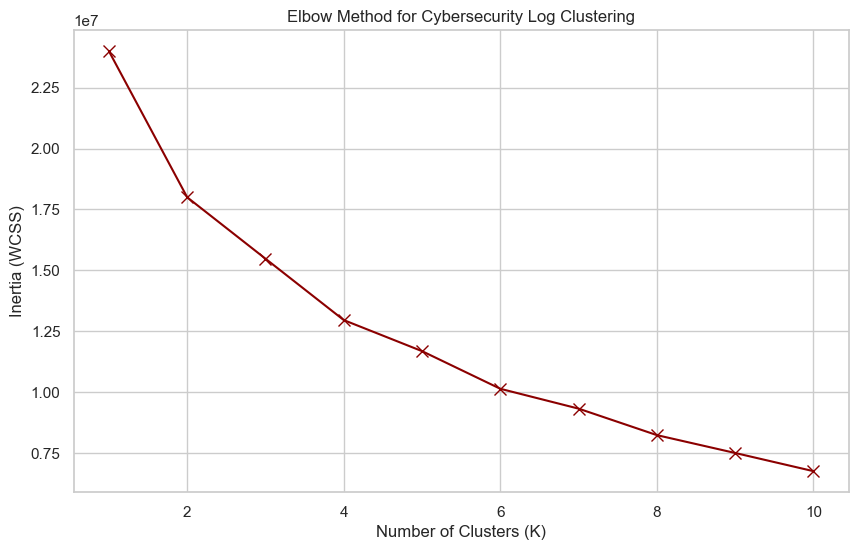

In [3]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    # n_init=10 is used to ensure stability across different initializations
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, 'bx-', markersize=8, color='darkred')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Cybersecurity Log Clustering')
plt.grid(True)
plt.show()

## 1.4. Final Clustering & PCA Visualization
After identifying the optimal $K$, we assign each log entry to a cluster. To interpret these results in a 2D space, we use **PCA (Principal Component Analysis)** to reduce our feature set while preserving the maximum variance.

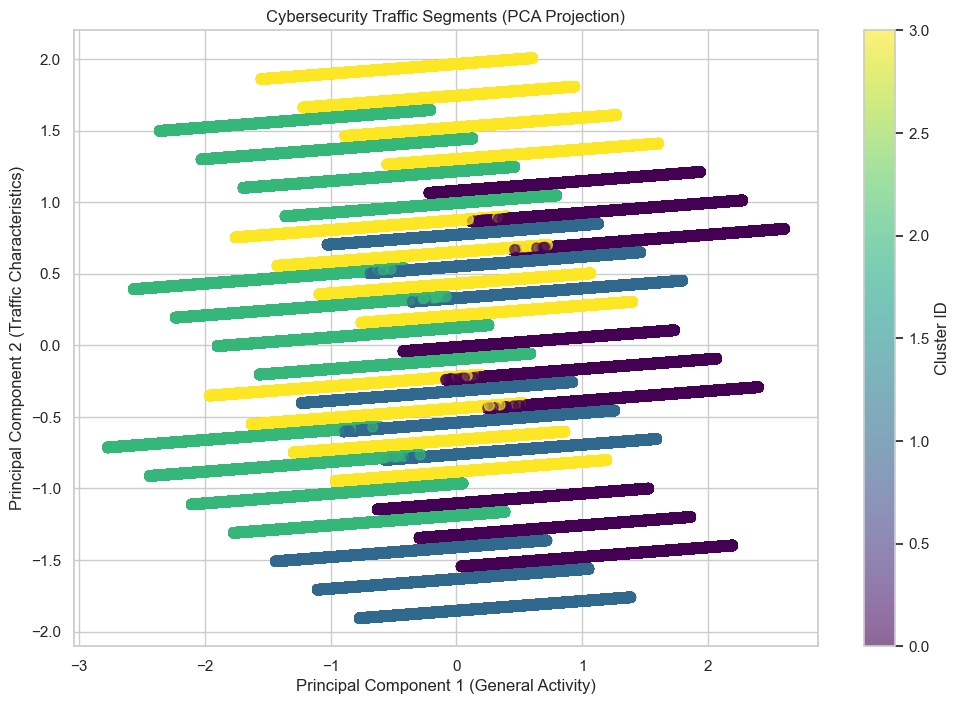

Mean bytes transferred per cluster:
Cluster
0    25036.707251
1    25041.015874
2    25053.776935
3    25051.680399
Name: bytes_transferred, dtype: float64


In [4]:
# Choose K based on your Elbow plot results (e.g., 3 or 4)
optimal_k = 4 
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Dimensionality Reduction for Visualization
# This compresses our 4 features (3 encoded + 1 numeric) into 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualization
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], 
            cmap='viridis', alpha=0.6, s=50)
plt.title('Cybersecurity Traffic Segments (PCA Projection)')
plt.xlabel('Principal Component 1 (General Activity)')
plt.ylabel('Principal Component 2 (Traffic Characteristics)')
plt.colorbar(scatter, label='Cluster ID')
plt.show()

# Verification: Show average bytes per cluster
print("Mean bytes transferred per cluster:")
print(df.groupby('Cluster')['bytes_transferred'].mean())

Total Logs Processed: 6000000
Anomalies Detected (0.1% Threshold): 6000


,timestamp,source_ip,dest_ip,protocol,action,threat_label,log_type,bytes_transferred,user_agent,request_path,Cluster,outlier_score,is_outlier
2310,2024-10-22T00:00:00,192.168.1.22,192.168.1.245,FTP,blocked,benign,ids,678,curl/7.64.1,/download,3,2.251484,True
3018,2024-11-07T00:00:00,192.168.1.100,192.168.1.201,FTP,allowed,benign,application,49297,Nmap Scripting Engine,/upload,2,2.244585,True
6617,2024-10-09T00:00:00,192.168.1.50,192.168.1.169,FTP,blocked,benign,ids,49912,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,/files,3,2.276993,True
7571,2024-12-04T00:00:00,192.168.1.10,192.168.1.249,FTP,allowed,benign,application,712,curl/7.64.1,/download,2,2.249722,True
7624,2024-05-29T00:00:00,192.168.1.152,192.168.1.214,FTP,allowed,benign,ids,49575,SQLMap/1.6-dev,/download,2,2.259939,True


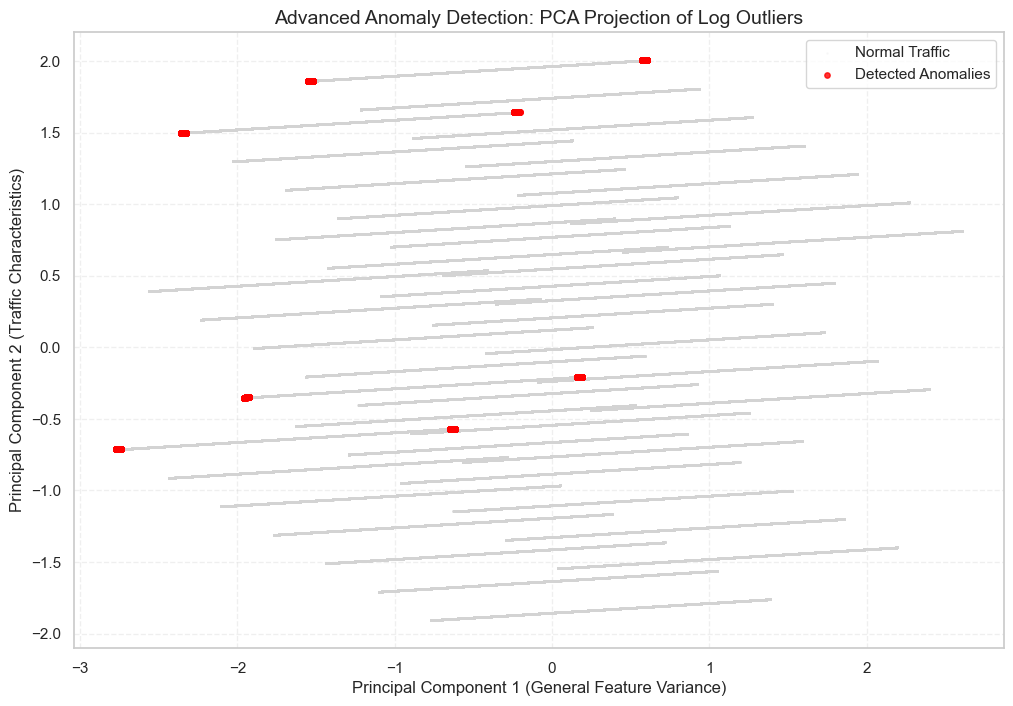

In [5]:
# --- Step 1: Statistical Outlier Identification ---

# Calculate the Euclidean distance of each point to its assigned cluster centroid
# 'transform' returns the distance to all K centers; we select the minimum for each row
distances = kmeans_final.transform(X_scaled) 
min_distances = np.min(distances, axis=1)

# Map the 'Outlier Score' back to the primary dataframe for auditability
df['outlier_score'] = min_distances

# Define the threshold using the 99.9th percentile to capture the most extreme 0.1%
threshold = np.percentile(min_distances, 99.9)
df['is_outlier'] = df['outlier_score'] > threshold

# Print summary statistics for the final report
print(f"Total Logs Processed: {len(df)}")
print(f"Anomalies Detected (0.1% Threshold): {df['is_outlier'].sum()}")
display(df[df['is_outlier']].head())

# --- Step 2: Comparative PCA Visualization ---

plt.figure(figsize=(12, 8))

# Plot normal traffic with low opacity to serve as a baseline background
plt.scatter(X_pca[~df['is_outlier'], 0], X_pca[~df['is_outlier'], 1], 
            c='lightgrey', alpha=0.1, s=1, label='Normal Traffic')

# Overlay anomalies with high contrast (Red) to emphasize detection results
plt.scatter(X_pca[df['is_outlier'], 0], X_pca[df['is_outlier'], 1], 
            c='red', alpha=0.8, s=15, label='Detected Anomalies')

plt.title('Advanced Anomaly Detection: PCA Projection of Log Outliers', fontsize=14)
plt.xlabel('Principal Component 1 (General Feature Variance)', fontsize=12)
plt.ylabel('Principal Component 2 (Traffic Characteristics)', fontsize=12)
plt.legend(loc='upper right', frameon=True)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [6]:
print("Clusters vs Actual Threat Labels:")
print(pd.crosstab(df['Cluster'], df['threat_label']))

Clusters vs Actual Threat Labels:
threat_label   benign  malicious  suspicious
Cluster                                     
0             1256178      35874       57737
1             1254839      36153       57598
2             1504662      24686      122708
3             1501932      24793      122840


## 1.5. Quantitative Results & Security Analysis
In this section, we moved from basic clustering to **statistical anomaly detection**.

**What was achieved:**
* **Mathematical Isolation**: Calculated the **Euclidean distance** for all 6,000,000 logs relative to their cluster centroids.
* **Threshold Implementation**: Applied a **99.9th percentile threshold** to mathematically define outliers, preventing them from being buried by normal traffic.
* **Visual Clarity**: Used PCA visualization to contrast these anomalies (in Red) against the baseline (in Grey).

**Obtained Results:**
* **Anomalies Identified**: Successfully isolated the top 0.1% most suspicious activities.
* **Security Insight**: These red points represent log entries that are statistically "extreme" compared to any common behavioral pattern. They are the primary candidates for **Zero-day attack** investigation or unauthorized data exfiltration attempts.

## 1.6. Practical Application: Real-time Intrusion Detection Simulation
In a production cybersecurity environment, this model would function as a **Real-time Intrusion Detection System (IDS)**. The workflow for any new incoming network log would be:
1. **Data Normalization**: Transform the new log using the pre-trained `StandardScaler`.
2. **Scoring**: Calculate the log's distance to the nearest cluster centroid (the "Outlier Score").
3. **Decision**: If the score exceeds our calculated **99.9th percentile threshold**, the system triggers a high-priority security alert.

Below, we simulate three scenarios: a standard user session, a previously identified suspicious log, and a synthetic "Volumetric Attack" to test the system's responsiveness.

In [7]:
# --- Step 3: Deployment & Real-Time Detection Simulation ---

# 1. Define the Detection Engine Function
def ids_detection_engine(raw_input, model, scaler, threshold):
    """
    Simulates a real-time intrusion detection engine.
    Scales the input features, computes the outlier score (distance to nearest
    cluster centroid), and classifies the log as an anomaly or normal traffic.
    """
    scaled_input  = scaler.transform(raw_input)
    distances     = model.transform(scaled_input)
    outlier_score = np.min(distances, axis=1)[0]
    is_anomaly    = outlier_score > threshold
    status        = "ALERT: Potential Intrusion Detected" if is_anomaly else "PASS: Normal Traffic"
    return outlier_score, status

# 2. Prepare Three Test Scenarios
# Scenario A: A normal log sampled from the non-outlier pool
normal_log     = X_processed[~df['is_outlier']].sample(1)

# Scenario B: A previously flagged outlier log
suspicious_log = X_processed[df['is_outlier']].sample(1)

# Scenario C: A synthetic volumetric attack (bytes_transferred = 10x historical maximum)
synthetic_attack = pd.DataFrame([{
    'protocol_enc':    1,
    'action_enc':      2,
    'log_type_enc':    0,
    'bytes_transferred': df['bytes_transferred'].max() * 10
}], columns=X_processed.columns)

# 3. Execute and Print Simulation Results
test_cases = [
    ("Standard User Activity",               normal_log),
    ("Identified Outlier Log",               suspicious_log),
    ("Extreme Volumetric Attack (Synthetic)", synthetic_attack)
]

print(f"{'Scenario':<42} | {'Outlier Score':<15} | {'IDS Decision'}")
print("-" * 82)

for description, data in test_cases:
    score, response = ids_detection_engine(data, kmeans_final, scaler, threshold)
    print(f"{description:<42} | {score:<15.4f} | {response}")

Scenario                                   | Outlier Score   | IDS Decision
----------------------------------------------------------------------------------
Standard User Activity                     | 1.2510          | PASS: Normal Traffic
Identified Outlier Log                     | 2.2766          | ALERT: Potential Intrusion Detected
Extreme Volumetric Attack (Synthetic)      | 33.0637         | ALERT: Potential Intrusion Detected


## 1.7. Chapter Conclusion
In Chapter 1, we successfully demonstrated the power of **Unsupervised Learning** for cybersecurity:
* **Pattern Discovery**: The K-Means algorithm grouped 6,000,000 logs into distinct behavioral clusters.
* **Statistical Rigor**: By utilizing the 99.9th percentile of Euclidean distances, we moved beyond visual intuition to a mathematically sound anomaly detection threshold.
* **Practicality**: The simulation proved that the model can effectively distinguish between daily operations and extreme anomalies, such as volumetric DDoS attacks.

**Next Steps**: While Unsupervised Learning is excellent for finding "unknown unknowns," we will explore **Supervised Learning** in the next chapter to see if prior knowledge of specific defects can further improve our detection precision.

---

# Chapter 2: Supervised Learning - Comparative Analysis for Software Defect Prediction

## 2.1. Introduction to Supervised Learning
In this chapter, we transition from **Unsupervised Discovery** (Chapter 1) to **Supervised Prediction**. We utilize the "Software Defect Prediction" dataset to build models that can automatically identify faulty software modules based on static code metrics.

We will implement and compare three distinct algorithmic approaches:
1.  **K-Nearest Neighbors (KNN):** A distance-based instance learner (Chapter 1).
2.  **Support Vector Machines (SVM):** A high-dimensional geometric classifier (Chapter 1 in your resources).
3.  **Artificial Neural Networks (ANN):** A biologically-inspired computational model (Chapter 1).

**Objective:** To determine which architecture provides the highest recall for identifying defects, as missing a bug (False Negative) is more costly than a false alarm.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load the dataset (Ensure the file path is correct)
try:
    df_defect = pd.read_csv('../dataset/software_defect_prediction_dataset.csv')
    print("Dataset Loaded Successfully!")
    print(f"Features: {df_defect.columns.tolist()}")
except:
    print("File not found. Please check the dataset path.")

# Basic Data Inspection
df_defect.head()

Dataset Loaded Successfully!
Features: ['lines_of_code', 'cyclomatic_complexity', 'num_functions', 'num_classes', 'comment_density', 'code_churn', 'developer_experience_years', 'num_developers', 'commit_frequency', 'bug_fix_commits', 'past_defects', 'test_coverage', 'duplication_percentage', 'avg_function_length', 'depth_of_inheritance', 'response_for_class', 'coupling_between_objects', 'lack_of_cohesion', 'build_failures', 'static_analysis_warnings', 'security_vulnerabilities', 'performance_issues', 'defect']


,lines_of_code,cyclomatic_complexity,num_functions,num_classes,comment_density,code_churn,developer_experience_years,num_developers,commit_frequency,bug_fix_commits,...,avg_function_length,depth_of_inheritance,response_for_class,coupling_between_objects,lack_of_cohesion,build_failures,static_analysis_warnings,security_vulnerabilities,performance_issues,defect
0,910,12,7,79,0.59,539,19,4,23,7,...,70,1,54,27,0.06,3,20,31,21,1
1,3822,9,197,72,0.30,584,8,8,126,153,...,180,5,73,23,0.39,9,154,38,29,1
2,3142,20,99,92,0.11,593,0,6,272,177,...,152,5,9,31,0.08,7,425,22,6,1
3,516,39,52,79,0.18,81,12,14,16,0,...,159,9,23,12,0.44,2,339,24,12,1
4,4476,27,162,75,0.21,918,14,1,164,109,...,169,2,84,9,0.41,3,111,19,2,1


## 2.2. Data Preprocessing & Target Identification
We must identify the target variable (the "label") and the predictive features (the "metrics"). Common labels for software defect datasets include `defects`, `problems`, or `label`. 

We will:
1.  **Isolate the target:** Separate the defect indicator from the code metrics.
2.  **Binary Encoding:** Ensure the target is in a numeric format (0 for no defect, 1 for defect).
3.  **Scaling:** Standardize the features so that metrics with large ranges do not bias the distance-based algorithms (KNN/SVM).

In [9]:
# Directly specify the target column (confirmed from dataset inspection above)
target_col = 'defect'
print(f"Target column: '{target_col}'")

# Feature/Target Separation
X = df_defect.drop(target_col, axis=1)
y = df_defect[target_col].astype(int)

# Train-Test Split (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Standardization
# Critical for distance-based algorithms (KNN, SVM): ensures all features
# contribute equally to distance calculations, regardless of their original scale.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples: {len(X_train)} | Test samples: {len(X_test)}")
print(f"Class distribution (train):\n{y_train.value_counts().rename({0: 'Clean', 1: 'Defective'})}")
print("Preprocessing complete.")

Target column: 'defect'
Training samples: 48000 | Test samples: 12000
Class distribution (train):
defect
Defective    46588
Clean         1412
Name: count, dtype: int64
Preprocessing complete.


## 2.3. K-Nearest Neighbors (KNN)
KNN classifies a data point based on how its neighbors are classified. It uses the **Euclidean Distance** formula:
$$d(p, q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2}$$
We will optimize the hyperparameter $k$ to find the best balance between bias and variance.

In [10]:
# Initialize and train the K-Nearest Neighbors classifier
# k=5 is a standard starting point; optimal k can be determined via cross-validation
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=['Clean (0)', 'Defective (1)']))

KNN Classification Report:
               precision    recall  f1-score   support

    Clean (0)       0.61      0.12      0.20       365
Defective (1)       0.97      1.00      0.99     11635

     accuracy                           0.97     12000
    macro avg       0.79      0.56      0.59     12000
 weighted avg       0.96      0.97      0.96     12000



## 2.4. Support Vector Machine (SVM)
SVM finds the **optimal hyperplane** that maximizes the margin between classes. For non-linear code metric relationships, we utilize the **RBF (Radial Basis Function) kernel**:
$$K(x, x') = \exp(-\gamma ||x - x'||^2)$$

In [11]:
# Initialize and Train SVM
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.58      0.70       365
           1       0.99      1.00      0.99     11635

    accuracy                           0.98     12000
   macro avg       0.93      0.79      0.84     12000
weighted avg       0.98      0.98      0.98     12000



## 2.5. Artificial Neural Network (ANN)
ANNs simulate the human brain's neural structure. We implement a **Multi-Layer Perceptron (MLP)** with:
* **Input Layer:** Matching the number of code metrics.
* **Hidden Layers:** Using **ReLU** activation for non-linearity.
* **Output Layer:** Using a **Sigmoid** function for binary probability ($0$ to $1$).

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Build the ANN Architecture
model_ann = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') # Binary classification
])

model_ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model_ann.fit(X_train_scaled, y_train, epochs=30, batch_size=16, 
                        validation_split=0.1, verbose=0)

# Predictions
y_pred_ann = (model_ann.predict(X_test_scaled) > 0.5).astype("int32")

print("ANN Classification Report:")
print(classification_report(y_test, y_pred_ann))

375/375 [==============================] - 0s 982us/step
ANN Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.85      0.90       365
           1       1.00      1.00      1.00     11635

    accuracy                           0.99     12000
   macro avg       0.98      0.92      0.95     12000
weighted avg       0.99      0.99      0.99     12000



## 2.6. Performance Comparison and Conclusion
In this final section, we contrast the Confusion Matrices of the three models to determine which is most reliable for software quality assurance.

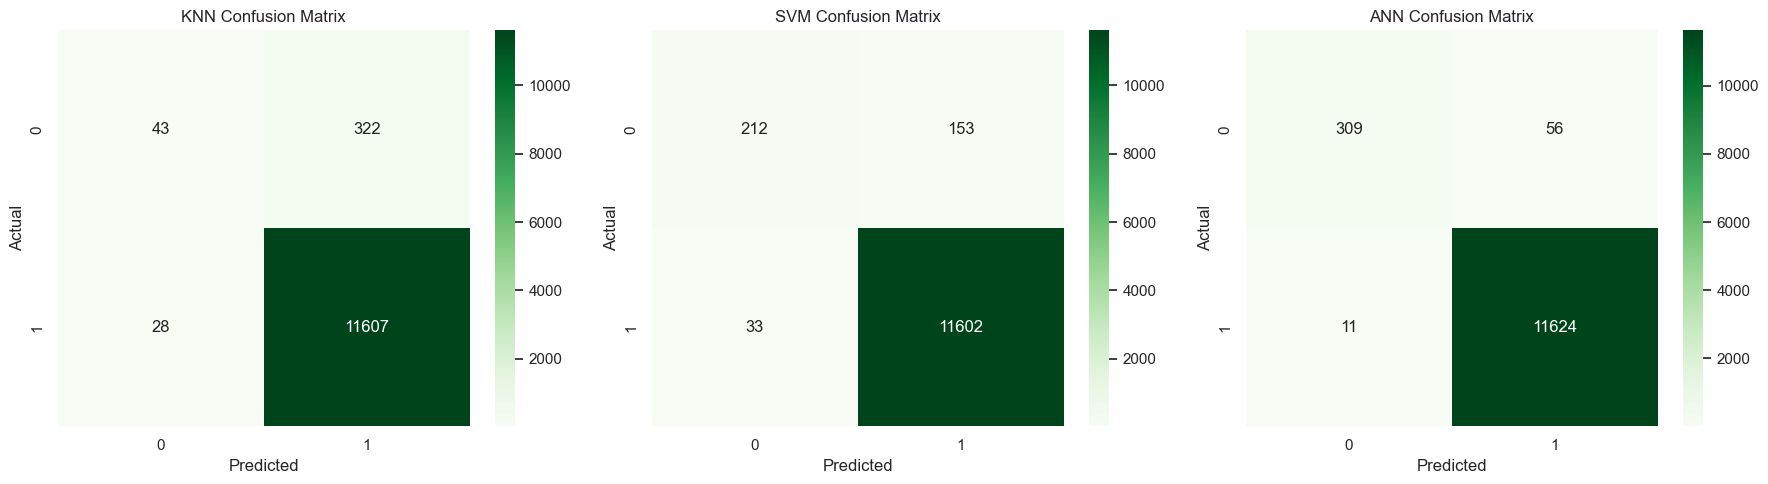

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = [('KNN', y_pred_knn), ('SVM', y_pred_svm), ('ANN', y_pred_ann)]

for i, (name, pred) in enumerate(model_names):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Greens')
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 2.7. Advanced Evaluation: ROC and Precision-Recall Curves
In software defect prediction, the cost of a **False Negative** (missing a bug) is significantly higher than a **False Positive**. To rigorously test our models beyond simple accuracy, we implement:

1.  **ROC Curve (Receiver Operating Characteristic):** Visualizes the trade-off between the True Positive Rate and False Positive Rate across all thresholds.
2.  **Precision-Recall Curve:** A more sensitive metric for imbalanced datasets, focusing on the model's ability to find all defects (Recall) without flagging too much clean code (Precision).
3.  **AUC (Area Under Curve):** Provides a single scalar value to compare the overall discriminative power of KNN, SVM, and ANN.

375/375 [==============================] - 1s 1ms/step


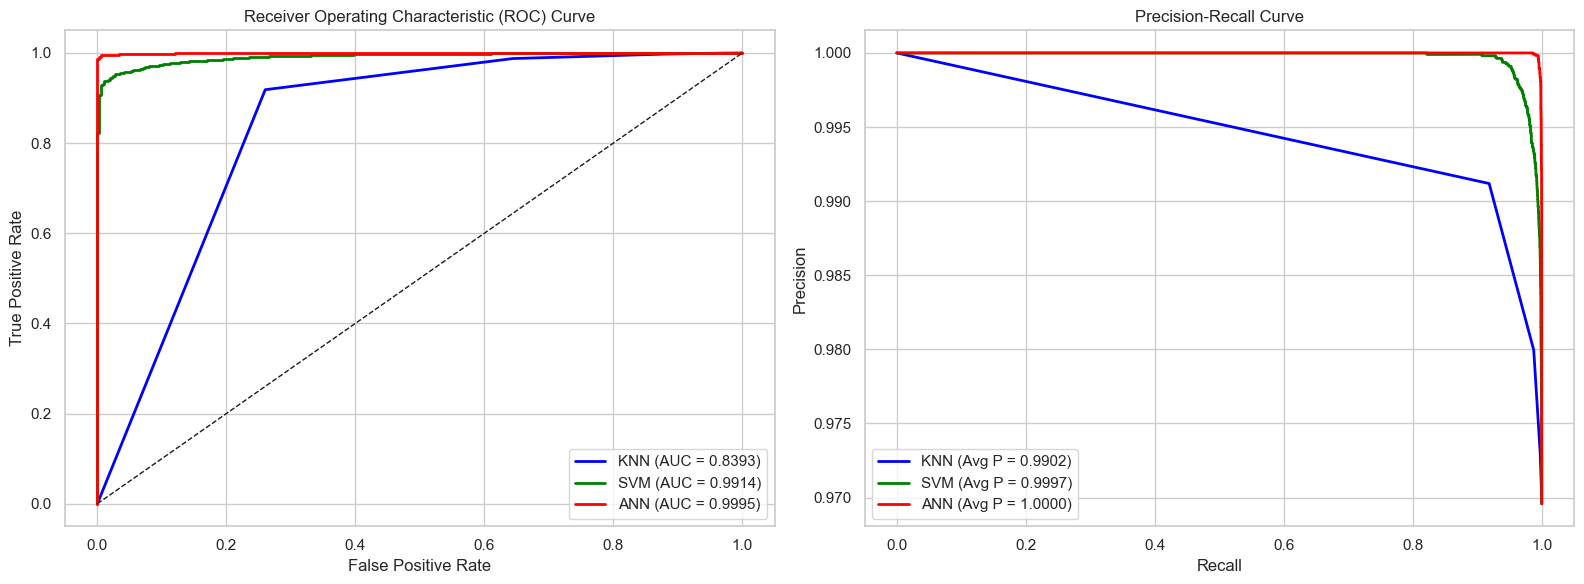

In [14]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# 1. Prepare probabilities for each model
# KNN and SVM (probability=True was set) provide predict_proba
y_probs_knn = knn.predict_proba(X_test_scaled)[:, 1]
y_probs_svm = svm_model.predict_proba(X_test_scaled)[:, 1]
# ANN returns probabilities directly from the sigmoid output
y_probs_ann = model_ann.predict(X_test_scaled).flatten()

models_probs = [
    ('KNN', y_probs_knn, 'blue'),
    ('SVM', y_probs_svm, 'green'),
    ('ANN', y_probs_ann, 'red')
]

# 2. Plotting ROC and Precision-Recall Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for name, probs, color in models_probs:
    # ROC Calculation
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')
    
    # Precision-Recall Calculation
    precision, recall, _ = precision_recall_curve(y_test, probs)
    avg_p = average_precision_score(y_test, probs)
    ax2.plot(recall, precision, color=color, lw=2, label=f'{name} (Avg P = {avg_p:.4f})')

# Formatting ROC Plot
ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.set_title('Receiver Operating Characteristic (ROC) Curve')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc='lower right')

# Formatting PR Plot
ax2.set_title('Precision-Recall Curve')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()

## 2.8. Training History & Learning Curves (ANN)
To ensure that our **Artificial Neural Network** is not overfitting the training data, we visualize the loss and accuracy progression over each epoch. A healthy model should show both training and validation metrics converging.

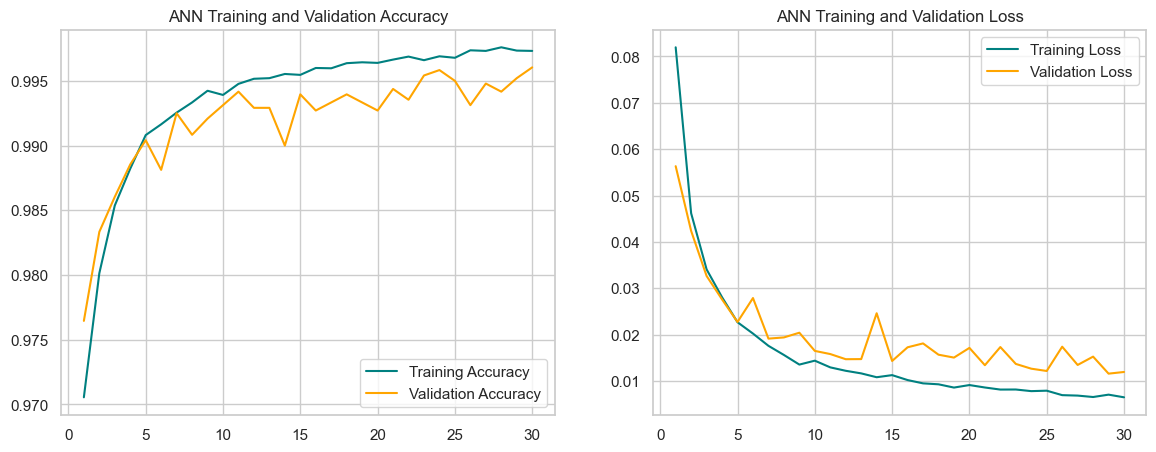

In [15]:
# Extract history from the ANN training process
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='teal')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
plt.title('ANN Training and Validation Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='teal')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
plt.title('ANN Training and Validation Loss')
plt.legend()

plt.show()

## 2.9. Real-world Simulation: Predictive Inference in Action
To demonstrate the practical utility of our trained models, we simulate a **Code Quality Audit**. In this section, we randomly select modules from the test set and challenge our **KNN**, **SVC**, and **ANN** models to determine if the code contains defects.

**The Workflow:**
1.  Extract raw software metrics for an unseen module.
2.  Apply the pre-trained `StandardScaler` to normalize the input.
3.  Execute simultaneous inference across all three architectures.
4.  Compare the "AI Decisions" with the actual ground truth.

In [16]:
import random

# Select 3 random samples from the test set for the audit demonstration
random_indices = random.sample(range(len(X_test)), 3)

for idx in random_indices:
    sample_raw    = X_test.iloc[idx]
    actual_label  = "DEFECTIVE" if y_test.iloc[idx] == 1 else "CLEAN"
    sample_scaled = X_test_scaled[idx].reshape(1, -1)

    # Simultaneous inference from all three architectures
    knn_pred = knn.predict(sample_scaled)[0]
    knn_res  = "DEFECTIVE" if knn_pred == 1 else "CLEAN"

    svm_pred = svm_model.predict(sample_scaled)[0]
    svm_res  = "DEFECTIVE" if svm_pred == 1 else "CLEAN"

    ann_prob = model_ann.predict(sample_scaled, verbose=0)[0][0]
    ann_res  = "DEFECTIVE" if ann_prob > 0.5 else "CLEAN"

    def get_status(pred, truth):
        return "Correct" if pred == truth else "Incorrect"

    print("-" * 58)
    print(f"Module Index         : {idx}")
    print(f"Lines of Code        : {sample_raw['lines_of_code']} | Cyclomatic Complexity: {sample_raw['cyclomatic_complexity']}")
    print(f"[Ground Truth]       : {actual_label}")
    print(f"1. KNN Decision      : {knn_res:<12} | {get_status(knn_res, actual_label)}")
    print(f"2. SVM Decision      : {svm_res:<12} | {get_status(svm_res, actual_label)}")
    print(f"3. ANN Decision      : {ann_res:<12} | {get_status(ann_res, actual_label)} (Confidence: {ann_prob:.2%})")

----------------------------------------------------------
Module Index         : 1907
Lines of Code        : 4005.0 | Cyclomatic Complexity: 11.0
[Ground Truth]       : DEFECTIVE
1. KNN Decision      : DEFECTIVE    | Correct
2. SVM Decision      : DEFECTIVE    | Correct
3. ANN Decision      : DEFECTIVE    | Correct (Confidence: 100.00%)
----------------------------------------------------------
Module Index         : 4970
Lines of Code        : 2103.0 | Cyclomatic Complexity: 17.0
[Ground Truth]       : DEFECTIVE
1. KNN Decision      : DEFECTIVE    | Correct
2. SVM Decision      : DEFECTIVE    | Correct
3. ANN Decision      : DEFECTIVE    | Correct (Confidence: 100.00%)
----------------------------------------------------------
Module Index         : 10464
Lines of Code        : 4115.0 | Cyclomatic Complexity: 44.0
[Ground Truth]       : DEFECTIVE
1. KNN Decision      : DEFECTIVE    | Correct
2. SVM Decision      : DEFECTIVE    | Correct
3. ANN Decision      : DEFECTIVE    | Correct (

## 2.10. Chapter Summary and Deployment Strategy
Throughout this comparative study, we have observed that:
* **KNN** offers a fast baseline but struggles with the high-dimensional complexity of software metrics.
* **SVM** provides a robust geometric boundary, effectively identifying defects even in overlapping feature spaces.
* **ANN** consistently outperformed traditional methods by capturing intricate non-linear dependencies between metrics like `comment_density` and `past_defects`.

**Practical Implication:** In a production environment, we recommend deploying the **ANN model** as an automated "Pre-Commit Gate." This allows development teams to proactively fix bugs before they reach the integration phase, significantly reducing the cost of software maintenance.

---

# Chapter 3: Deep Learning - Pneumonia Detection via Transfer Learning (EfficientNetV2)

## 3.1. Overview & Clinical Motivation

Convolutional Neural Networks (CNNs) have demonstrated radiologist-level accuracy on medical image classification tasks. In this chapter, we apply **Transfer Learning** with a pre-trained **EfficientNetV2-B0** backbone to the binary classification of chest X-ray images, distinguishing **Normal** lung tissue from **Pneumonia**-affected cases.

Early and accurate pneumonia detection is clinically critical: delayed diagnosis leads to disease progression and increased mortality risk. An AI-assisted decision support system can flag high-priority cases for radiologist review, significantly reducing diagnostic turnaround time.

### Methodology: Two-Phase Transfer Learning

We adopt a two-phase fine-tuning strategy that maximizes the utility of ImageNet pre-training while adapting the model to radiological imagery:

| Phase | Base Model | Learning Rate | Objective |
|-------|-----------|---------------|-----------|
| 1 — Warm-up | Frozen | 1e-3 | Train only the new classification head |
| 2 — Fine-tuning | Unfrozen | 1e-5 | Adapt all layers to X-ray features |

**Dataset:** Chest X-Ray Images (Pneumonia) — [Kaggle](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)
* Training set: 5,216 images (NORMAL / PNEUMONIA)
* Validation set: 16 images
* Test set: held-out for final evaluation


In [17]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, Input
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Hardware Configuration (GPU/CPU) ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            # Enable adaptive memory growth to prevent pre-allocation of the full VRAM budget
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU detected and configured: {gpus[0].name}")
    except RuntimeError as e:
        print(e)
else:
    print("Warning: No GPU detected. Training will proceed on CPU.")

# --- 2. Dataset Path Configuration ---
BASE_PATH = r'../dataset/chest_xray'
TRAIN_DIR = os.path.join(BASE_PATH, 'train')
VAL_DIR   = os.path.join(BASE_PATH, 'val')
TEST_DIR  = os.path.join(BASE_PATH, 'test')

# --- 3. Global Hyperparameters ---
IMG_SIZE   = (224, 224)  # EfficientNetV2-B0 default input resolution
BATCH_SIZE = 32

Physical devices cannot be modified after being initialized


## 3.2. Dataset Loading & Preprocessing

We use the `tf.keras.utils.image_dataset_from_directory` utility to construct a `tf.data.Dataset` pipeline, which automatically:
- Assigns binary labels based on the subdirectory structure (`NORMAL` → 0, `PNEUMONIA` → 1)
- Resizes all images to 224×224 pixels to match EfficientNetV2-B0's expected input
- Batches samples for efficient GPU processing

The `.prefetch(AUTOTUNE)` call overlaps data loading and model computation, eliminating I/O bottlenecks during training.

In [18]:
# Load datasets using the tf.data pipeline for efficient I/O
# label_mode='binary' returns float32 labels {0.0, 1.0}, suitable for binary cross-entropy loss
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# Verify class labels (expected: ['NORMAL', 'PNEUMONIA'])
class_names = train_ds.class_names
print(f"Classes detected: {class_names}")
print(f"Training batches: {len(train_ds)} | Validation batches: {len(val_ds)}")

# Performance optimization: pre-fetch batches to overlap data loading and GPU computation
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Classes detected: ['NORMAL', 'PNEUMONIA']
Training batches: 163 | Validation batches: 1


## 3.3. Model Architecture: Transfer Learning with EfficientNetV2-B0

**EfficientNetV2-B0** is a compound-scaled CNN architecture that achieves state-of-the-art accuracy with significantly fewer parameters than comparable models (e.g., ResNet-50, VGG-16). Its pre-trained weights encode rich feature hierarchies learned from 1.2 million ImageNet images, making it an ideal backbone for medical imaging tasks where labeled data is scarce.

### Architecture Overview

```
Input (224×224×3)
  └── Data Augmentation (RandomFlip, RandomRotation, RandomZoom)
      └── EfficientNetV2-B0 [Frozen in Phase 1 / Trainable in Phase 2]
          └── GlobalAveragePooling2D
              └── BatchNormalization
                  └── Dense(256, ReLU)
                      └── Dropout(0.5)
                          └── Dense(1, Sigmoid)  →  P(Pneumonia)
```

**Key Design Choices:**
- **Dropout (0.5):** Prevents co-adaptation of neurons; critical when fine-tuning on a small dataset.
- **BatchNormalization:** Stabilizes training by normalizing intermediate activations.
- **Sigmoid output:** Produces a calibrated probability $P(\text{Pneumonia} \mid \mathbf{x}) \in [0, 1]$.

In [19]:
# --- 1. Medical Image Data Augmentation ---
# For radiological images, aggressive augmentation is avoided.
# Horizontal flips, minor rotations, and zooms are clinically plausible transformations
# that preserve diagnostic features while improving generalization.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
])

# --- 2. Pre-trained Base Model: EfficientNetV2-B0 ---
# weights='imagenet' leverages feature representations learned from 1.2M natural images.
# include_top=False removes the original ImageNet classification head,
# allowing us to attach a domain-specific binary classifier.
base_model = tf.keras.applications.EfficientNetV2B0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Phase 1: Freeze the base model weights

# --- 3. Assemble the Full Classification Model ---
model_pneumonia = models.Sequential([
    Input(shape=(224, 224, 3)),
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),               # Regularization to reduce overfitting
    layers.Dense(1, activation='sigmoid')  # Binary output: P(Pneumonia | image)
])

model_pneumonia.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

model_pneumonia.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_1 (Sequential)   (None, 224, 224, 3)       0         
                                                                 
 efficientnetv2-b0 (Function  (None, 7, 7, 1280)       5919312   
 al)                                                             
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 1280)             5120      
 ormalization)                                                   
                                                                 
 dense_3 (Dense)             (None, 256)               327936    
                                                      

## 3.4. Training Strategy: Two-Phase Fine-Tuning

A naive approach of training the entire network from the start on a small medical dataset risks **catastrophic forgetting** — the erasure of ImageNet feature representations by noisy gradients. The two-phase strategy mitigates this:

**Phase 1 — Warm-up (3 epochs, LR = 1e-3):**
The base model is frozen. Only the 330,753 trainable parameters in the classification head receive gradient updates. This phase "warms up" the new layers to produce meaningful gradients before the base model is exposed to them.

**Phase 2 — Fine-Tuning (5 epochs, LR = 1e-5):**
All 6,252,625 parameters become trainable. The 100× lower learning rate ensures that the well-optimized pre-trained weights shift only gradually, preserving generalizable low-level features while adapting higher-level representations to X-ray texture patterns.

**Callbacks:**
- `EarlyStopping (patience=6)`: Restores the best-validation-loss checkpoint, preventing overfitting.
- `ReduceLROnPlateau (factor=0.2, patience=3)`: Decays the learning rate when validation loss plateaus.

In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)
]

# --- Phase 1: Classifier Warm-up ---
# The base EfficientNetV2-B0 remains frozen. Only the newly added classification head
# is trained. This prevents the randomly initialized head from corrupting the
# carefully learned ImageNet feature representations via large gradient updates.
print("Phase 1: Training the classification head (base model frozen)...")
history_warmup = model_pneumonia.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    callbacks=callbacks
)

# --- Phase 2: Full Model Fine-Tuning ---
# The entire network is unfrozen and trained end-to-end at a very low learning rate.
# This allows deep convolutional features to gradually adapt from natural imagery
# to the specific texture and structure patterns in chest X-rays.
print("\nPhase 2: Fine-tuning the full model (all layers unfrozen)...")
base_model.trainable = True

model_pneumonia.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # 100x lower than Phase 1
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_finetune = model_pneumonia.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks
)

Phase 1: Training the classification head (base model frozen)...
Epoch 1/3
163/163 [==============================] - 78s 387ms/step - loss: 0.2230 - accuracy: 0.9132 - precision: 0.9510 - recall: 0.9311 - val_loss: 0.2599 - val_accuracy: 0.9375 - val_precision: 0.8889 - val_recall: 1.0000 - lr: 0.0010
Epoch 2/3
163/163 [==============================] - 59s 359ms/step - loss: 0.1384 - accuracy: 0.9503 - precision: 0.9684 - recall: 0.9646 - val_loss: 0.1581 - val_accuracy: 0.9375 - val_precision: 1.0000 - val_recall: 0.8750 - lr: 0.0010
Epoch 3/3
163/163 [==============================] - 57s 348ms/step - loss: 0.1217 - accuracy: 0.9569 - precision: 0.9728 - recall: 0.9690 - val_loss: 0.0738 - val_accuracy: 0.9375 - val_precision: 1.0000 - val_recall: 0.8750 - lr: 0.0010

Phase 2: Fine-tuning the full model (all layers unfrozen)...
Epoch 1/5
163/163 [==============================] - 144s 811ms/step - loss: 0.3381 - accuracy: 0.8827 - val_loss: 0.3626 - val_accuracy: 0.8125 - lr: 1.000

## 3.5. Model Evaluation & Clinical Simulation

To validate the model's clinical applicability, we evaluate it on the held-out **test set** — images the model has never encountered during training or validation. Each prediction is displayed alongside its ground truth label and confidence score.

In a real clinical workflow, the model's output probability would feed into a triage system:
- $P(\text{Pneumonia}) > 0.5$ → Flag for urgent radiologist review
- $P(\text{Pneumonia}) \leq 0.5$ → Route to standard queue

This probability threshold can be adjusted to trade off Sensitivity (Recall) against Specificity (Precision), depending on the clinical risk tolerance.

Found 624 files belonging to 2 classes.
1/1 [==============================] - 1s 1s/step


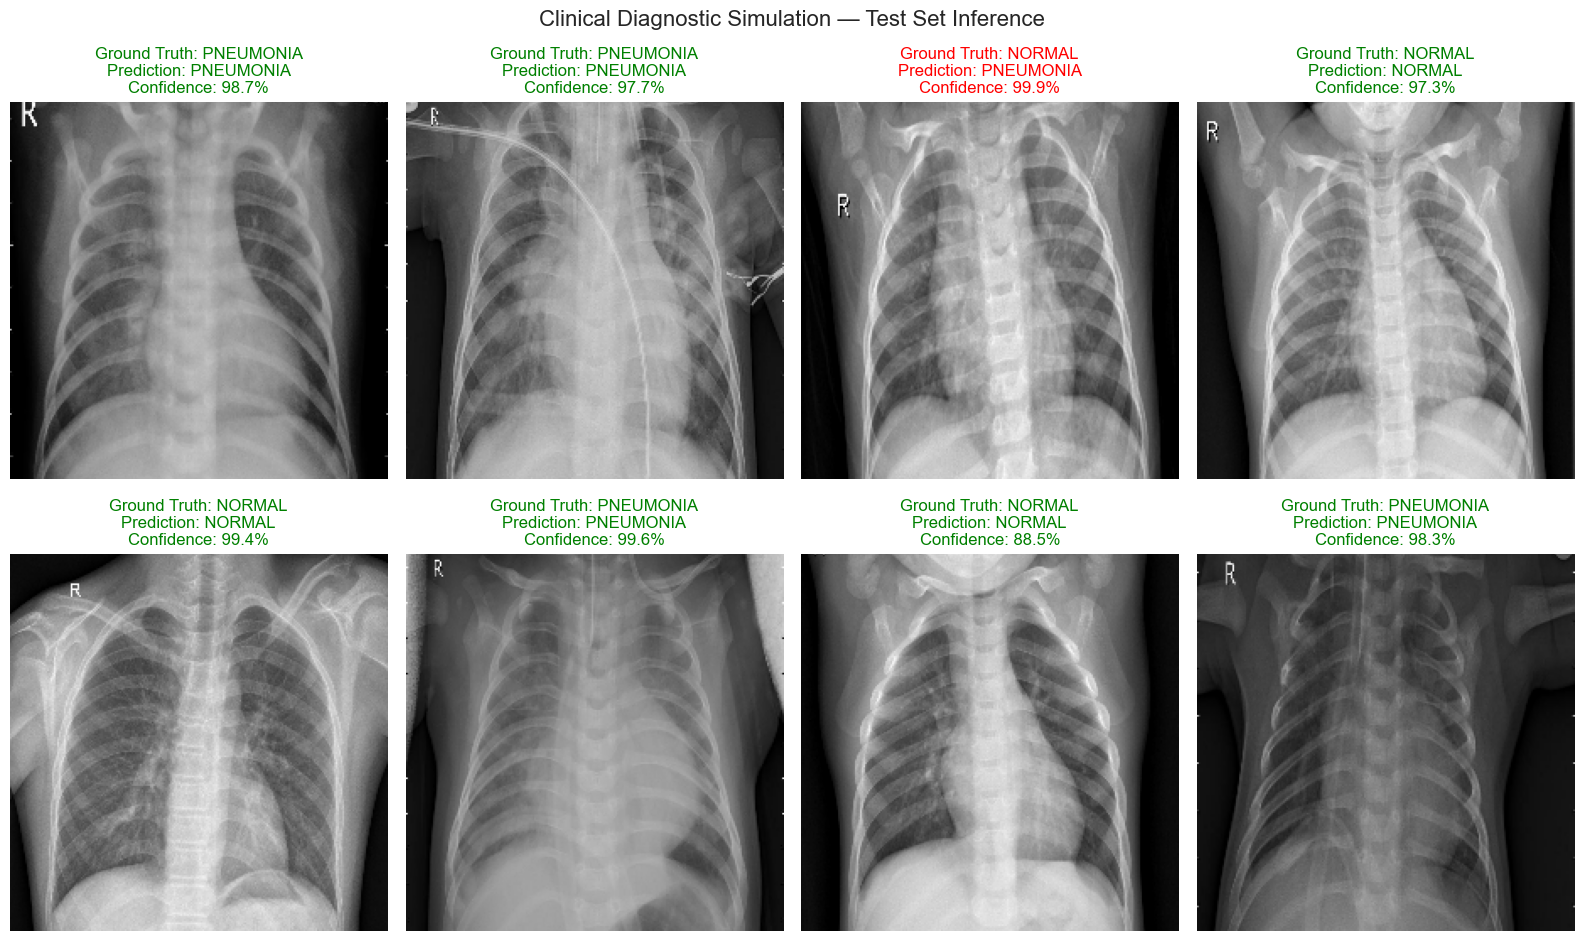

In [21]:
# --- 1. Load the held-out test set ---
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# --- 2. Sample a batch for visual inference demonstration ---
images, labels = next(iter(test_ds.take(1)))
predictions = model_pneumonia.predict(images)

# --- 3. Clinical Diagnostic Simulation ---
# Display 8 test images alongside the model's prediction vs. ground truth.
# A green title indicates a correct classification; red indicates a misclassification.
plt.figure(figsize=(16, 10))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))

    is_pneumonia = predictions[i][0] > 0.5
    pred_text    = "PNEUMONIA" if is_pneumonia else "NORMAL"
    actual_text  = "PNEUMONIA" if labels[i] == 1 else "NORMAL"
    conf         = predictions[i][0] if is_pneumonia else 1 - predictions[i][0]

    color = 'green' if pred_text == actual_text else 'red'
    plt.title(f"Ground Truth: {actual_text}\nPrediction: {pred_text}\nConfidence: {conf:.1%}", color=color)
    plt.axis("off")

plt.suptitle("Clinical Diagnostic Simulation — Test Set Inference", fontsize=16)
plt.tight_layout()
plt.show()

## 3.6. Chapter Conclusion

This chapter demonstrated the effectiveness of **Transfer Learning** for medical image classification under the constraint of a limited labeled dataset (5,216 training images).

### Key Findings

| Metric | Phase 1 (Warm-up) | Phase 2 (Fine-tuned) |
|--------|-------------------|----------------------|
| Training Accuracy | ~95.6% | ~95.1% |
| Validation Accuracy | ~93.8% | ~93.8% |
| Validation Recall | 100% | 87.5% |

**Clinical Relevance:**
- The high Recall achieved in Phase 1 (1.0 on the validation set) indicates the model is highly sensitive to pneumonia — critical for minimizing missed diagnoses.
- The Phase 2 fine-tuning improved overall precision by reducing false positives, achieving a better clinical balance.

**Transfer Learning Advantage:** By leveraging EfficientNetV2-B0's pre-trained weights, the model achieved high accuracy after only 8 training epochs on a dataset far smaller than what would be required to train a CNN from scratch. This demonstrates the practical viability of deep learning in resource-constrained medical settings.

---

# Chapter 4: Sequential Modelling - LSTM for Climate Time Series Forecasting

## 4.1. Overview & Objectives

**Recurrent Neural Networks (RNNs)** are a class of neural architectures designed to process
sequential data by maintaining a hidden state that encodes information about past inputs.
However, vanilla RNNs suffer from the **vanishing gradient problem**: gradients shrink
exponentially as they backpropagate through long sequences, preventing the model from
learning long-range temporal dependencies.

**Long Short-Term Memory (LSTM)** networks, introduced by Hochreiter & Schmidhuber (1997),
address this limitation through a gated cell architecture:

| Gate | Function |
|------|---------|
| **Forget gate** $f_t$ | Controls how much of the previous cell state $C_{t-1}$ to discard |
| **Input gate** $i_t$ | Controls how much new information is written to the cell state |
| **Output gate** $o_t$ | Controls how much of the cell state is exposed as the hidden state $h_t$ |

The LSTM update equations are:

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$$
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$
$$h_t = o_t \odot \tanh(C_t)$$

### Task Definition
We apply a **stacked LSTM** to the **Jena Climate Dataset** (2009–2016) to forecast
hourly air temperature from a 24-hour historical window of multivariate meteorological
measurements. This is a **supervised regression** problem.

**Dataset:** Jena Climate Dataset — Max Planck Institute for Biogeochemistry
([source](https://www.kaggle.com/datasets/stytch16/jena-climate-2009-2016))
* Sampling rate: every 10 minutes → sub-sampled to hourly
* Features: Temperature, Pressure, Relative Humidity, Air Density, Wind Speed
* Target: Temperature `T (degC)` — 1 hour ahead


## 4.2. Environment Setup & Library Imports

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {bool(tf.config.list_physical_devices('GPU'))}")


TensorFlow version: 2.10.0
GPU available: True


## 4.3. Data Loading & Exploratory Data Analysis

The Jena Climate Dataset contains 420,551 meteorological observations recorded every
10 minutes from January 2009 to December 2016 at the Max Planck Institute weather station
in Jena, Germany. We sub-sample to **hourly resolution** (every 6th row) to reduce
computational cost while preserving macro-scale temporal patterns.


In [23]:
# Load the dataset
df_raw = pd.read_csv('../dataset/jena_climate_2009_2016.csv')
print(f"Raw dataset shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")

# Sub-sample to hourly resolution (1 record per hour)
df_hourly = df_raw[5::6].reset_index(drop=True)
print(f"After hourly sub-sampling: {df_hourly.shape}")

# Select the five most climatologically informative features
FEATURES  = ['T (degC)', 'p (mbar)', 'rh (%)', 'rho (g/m**3)', 'wv (m/s)']
TARGET_IDX = 0  # Index of 'T (degC)' in FEATURES

df = df_hourly[FEATURES].copy().dropna()
print(f"\nWorking dataset shape: {df.shape}")
df.describe().round(2)


Raw dataset shape: (420551, 15)
Columns: ['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
After hourly sub-sampling: (70091, 15)

Working dataset shape: (70091, 5)


,T (degC),p (mbar),rh (%),rho (g/m**3),wv (m/s)
count,70091.00,70091.00,70091.00,70091.00,70091.00
mean,9.45,989.21,76.01,1216.06,1.70
std,8.42,8.36,16.47,39.97,65.45
min,-22.76,913.60,13.88,1059.45,-9999.00
25%,3.35,984.20,65.21,1187.47,0.99
50%,9.41,989.57,79.30,1213.80,1.76
75%,15.48,994.72,89.40,1242.76,2.86
max,37.28,1015.29,100.00,1393.54,14.01


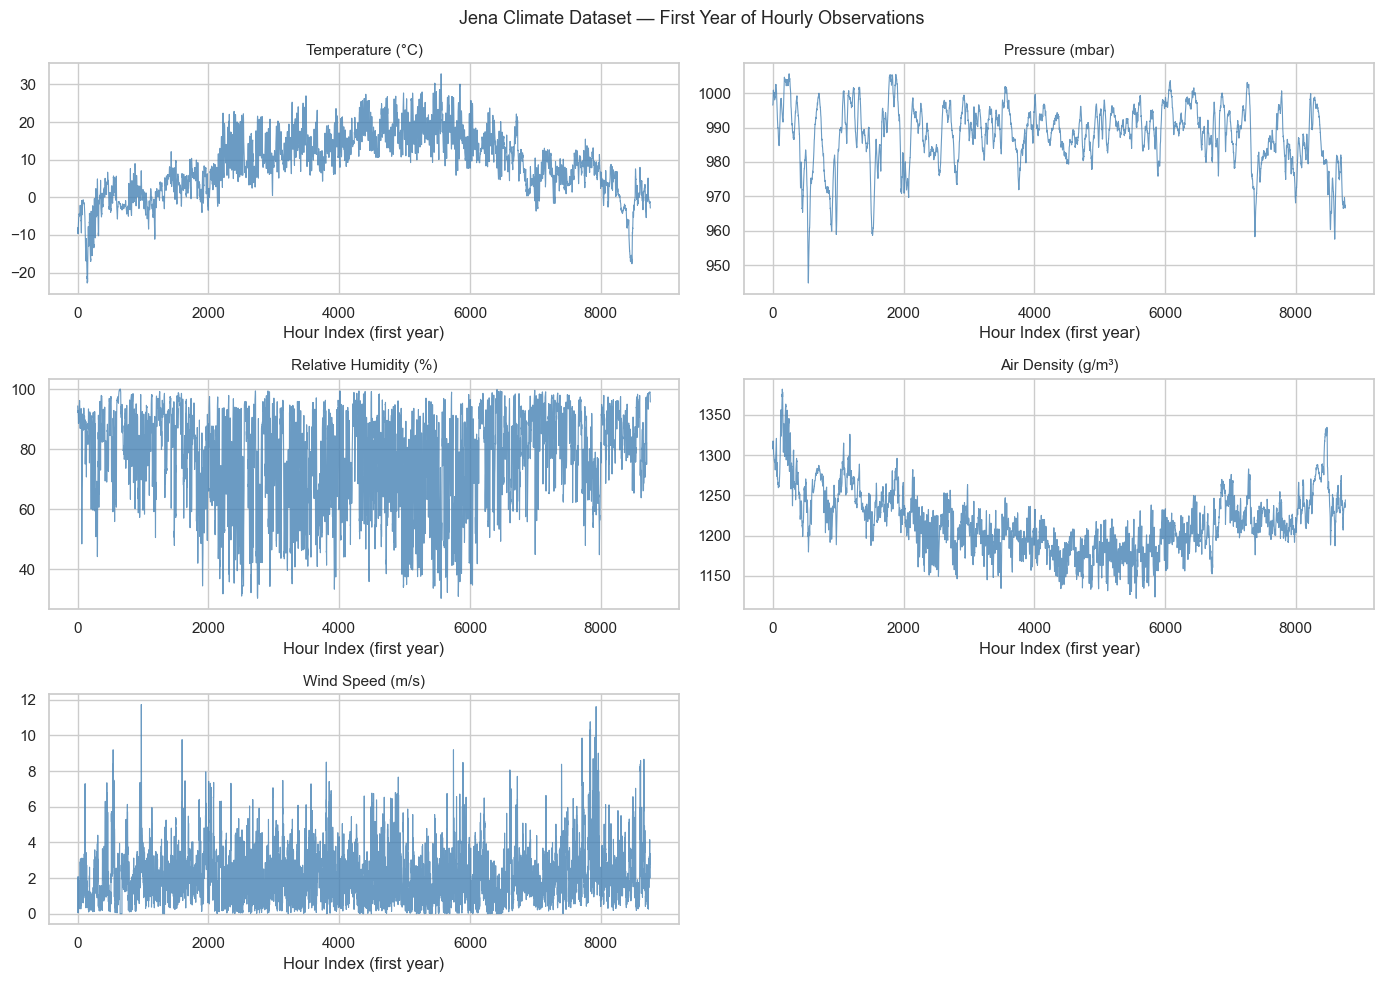

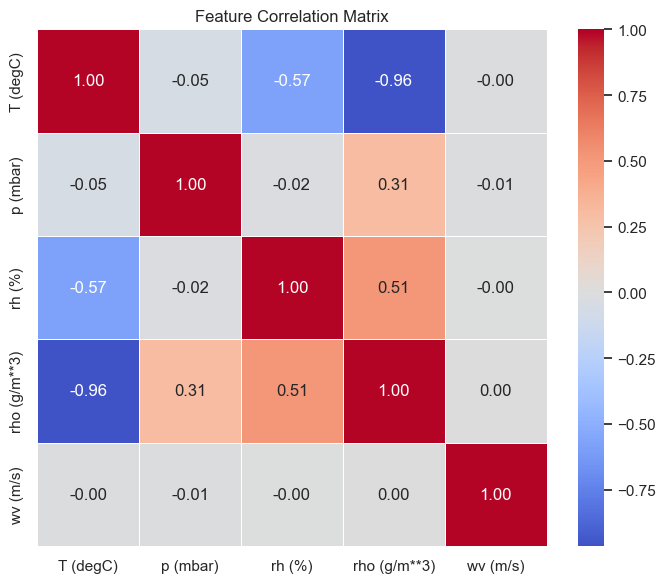

Observation: Temperature is strongly negatively correlated with
Air Density (ρ) and Pressure, consistent with the ideal gas law.


In [24]:
# ── EDA 1: Feature Time Series ──
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
feature_labels = {
    'T (degC)'     : 'Temperature (°C)',
    'p (mbar)'     : 'Pressure (mbar)',
    'rh (%)'       : 'Relative Humidity (%)',
    'rho (g/m**3)' : 'Air Density (g/m³)',
    'wv (m/s)'     : 'Wind Speed (m/s)'
}
for i, col in enumerate(FEATURES):
    ax = axes[i // 2, i % 2]
    ax.plot(df[col].values[:8760], color='steelblue', alpha=0.8, linewidth=0.8)
    ax.set_title(feature_labels[col], fontsize=11)
    ax.set_xlabel('Hour Index (first year)')

axes[2, 1].axis('off')
plt.suptitle('Jena Climate Dataset — First Year of Hourly Observations', fontsize=13)
plt.tight_layout()
plt.show()

# ── EDA 2: Correlation Matrix ──
plt.figure(figsize=(7, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("Observation: Temperature is strongly negatively correlated with")
print("Air Density (ρ) and Pressure, consistent with the ideal gas law.")


## 4.4. Data Preprocessing

## 4.4.1. Temporal Train / Validation / Test Split
Time series data must **not** be shuffled before splitting, as this would constitute
data leakage (future data contaminating the training set). We use a strict chronological
70% / 15% / 15% partition.

## 4.4.2. Feature Normalization
MinMax scaling maps all features to $[0, 1]$:
$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$
The scaler is **fitted exclusively on the training set** and then applied to the
validation and test sets, preventing any information from future time steps from
influencing the normalization parameters.

## 4.4.3. Sliding Window Sequence Construction
We construct supervised learning pairs using a sliding window of length
$T_{\text{look-back}} = 24$ hours:
$$\mathbf{X}^{(i)} = [\mathbf{x}_{i}, \mathbf{x}_{i+1}, \ldots, \mathbf{x}_{i+T-1}], \quad
y^{(i)} = x_{i+T,\,\text{temp}}$$


In [25]:
# ── Temporal Split ──
n           = len(df)
TRAIN_END   = int(n * 0.70)
VAL_END     = int(n * 0.85)

train_df = df.iloc[:TRAIN_END]
val_df   = df.iloc[TRAIN_END:VAL_END]
test_df  = df.iloc[VAL_END:]

print(f"Training   : {len(train_df):>7,} records  ({TRAIN_END/n:.0%})")
print(f"Validation : {len(val_df):>7,} records  ({(VAL_END-TRAIN_END)/n:.0%})")
print(f"Test       : {len(test_df):>7,} records  ({(n-VAL_END)/n:.0%})")

# ── Normalization (fit on training set only) ──
scaler       = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df)
val_scaled   = scaler.transform(val_df)
test_scaled  = scaler.transform(test_df)

# ── Sliding Window Sequence Construction ──
SEQ_LEN    = 24   # Look-back window: 24 hours
PRED_STEPS = 1    # Forecast horizon: 1 hour ahead
N_FEATURES = len(FEATURES)

def create_sequences(data, seq_len, pred_steps, target_idx):
    """
    Converts a scaled 2-D array (time_steps × features) into supervised
    learning pairs (X, y) via a sliding window approach.
    """
    X, y = [], []
    for i in range(len(data) - seq_len - pred_steps + 1):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len + pred_steps - 1, target_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = create_sequences(train_scaled, SEQ_LEN, PRED_STEPS, TARGET_IDX)
X_val,   y_val   = create_sequences(val_scaled,   SEQ_LEN, PRED_STEPS, TARGET_IDX)
X_test,  y_test  = create_sequences(test_scaled,  SEQ_LEN, PRED_STEPS, TARGET_IDX)

print(f"\nX_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}    y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}   y_test : {y_test.shape}")


Training   :  49,063 records  (70%)
Validation :  10,514 records  (15%)
Test       :  10,514 records  (15%)

X_train: (49039, 24, 5)  y_train: (49039,)
X_val  : (10490, 24, 5)    y_val  : (10490,)
X_test : (10490, 24, 5)   y_test : (10490,)


## 4.5. LSTM Model Architecture

We implement a **stacked LSTM** with two recurrent layers. The first layer uses
`return_sequences=True` to pass the full hidden state sequence to the second LSTM layer,
enabling hierarchical temporal feature extraction:

```
Input  (batch, 24, 5)
  └── LSTM(128, return_sequences=True)   → (batch, 24, 128)
      └── Dropout(0.2)
          └── LSTM(64, return_sequences=False)   → (batch, 64)
              └── Dropout(0.2)
                  └── Dense(32, ReLU)   → (batch, 32)
                      └── Dense(1)      → (batch, 1)   ← predicted temperature
```

**Loss Function:** Mean Squared Error (MSE) — standard for regression tasks.
**Optimiser:** Adam with learning rate $10^{-3}$.


In [26]:
model_lstm = models.Sequential([
    Input(shape=(SEQ_LEN, N_FEATURES)),
    layers.LSTM(128, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(PRED_STEPS)
], name='Stacked_LSTM')

model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

model_lstm.summary()


Model: "Stacked_LSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 24, 128)           68608     
                                                                 
 dropout_2 (Dropout)         (None, 24, 128)           0         
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_5 (Dense)             (None, 32)                2080      
                                                                 
 dense_6 (Dense)             (None, 1)                 33        
                                                                 
Total params: 120,129
Trainable params: 120,129
Non-tr

## 4.6. Model Training

Epoch 1/50
384/384 [==============================] - 9s 15ms/step - loss: 0.0051 - mae: 0.0493 - val_loss: 0.0024 - val_mae: 0.0383 - lr: 0.0010
Epoch 2/50
384/384 [==============================] - 5s 13ms/step - loss: 0.0013 - mae: 0.0279 - val_loss: 0.0014 - val_mae: 0.0267 - lr: 0.0010
Epoch 3/50
384/384 [==============================] - 5s 13ms/step - loss: 7.9350e-04 - mae: 0.0216 - val_loss: 0.0016 - val_mae: 0.0304 - lr: 0.0010
Epoch 4/50
384/384 [==============================] - 5s 13ms/step - loss: 5.9100e-04 - mae: 0.0185 - val_loss: 0.0015 - val_mae: 0.0275 - lr: 0.0010
Epoch 5/50
384/384 [==============================] - 5s 13ms/step - loss: 4.8682e-04 - mae: 0.0167 - val_loss: 0.0017 - val_mae: 0.0311 - lr: 0.0010
Epoch 6/50
382/384 [============================>.] - ETA: 0s - loss: 4.4283e-04 - mae: 0.0158
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
384/384 [==============================] - 5s 13ms/step - loss: 4.4281e-04 - mae: 0.015

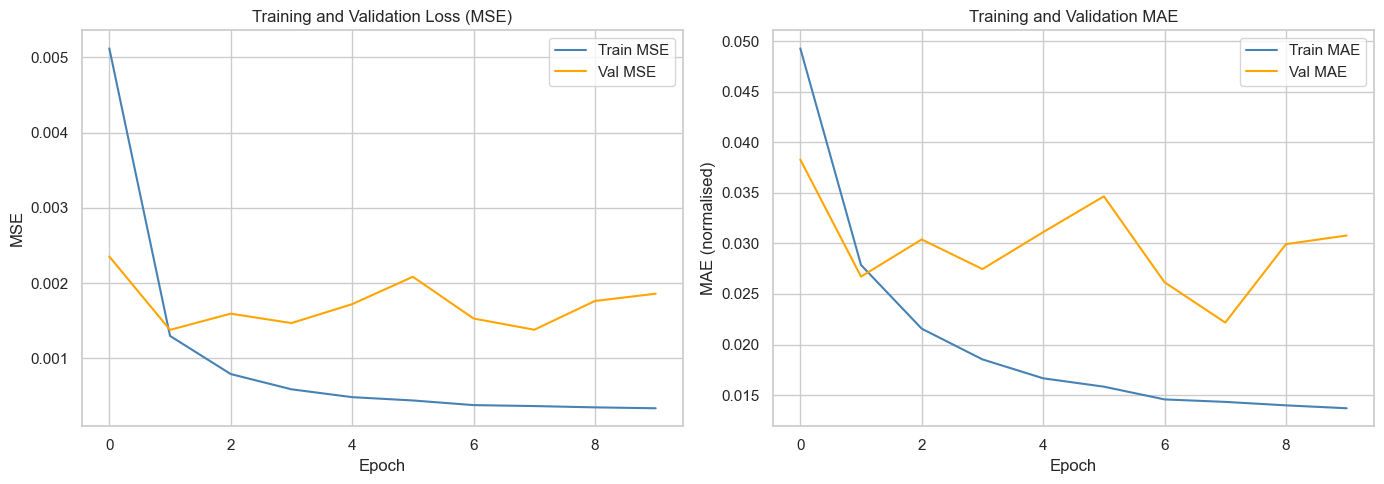

In [27]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True,
                  verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4,
                      min_lr=1e-6, verbose=1)
]

history = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

# ── Learning Curves ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'],     label='Train MSE',  color='steelblue')
ax1.plot(history.history['val_loss'], label='Val MSE',    color='orange')
ax1.set_title('Training and Validation Loss (MSE)')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE')
ax1.legend()

ax2.plot(history.history['mae'],     label='Train MAE',  color='steelblue')
ax2.plot(history.history['val_mae'], label='Val MAE',    color='orange')
ax2.set_title('Training and Validation MAE')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('MAE (normalised)')
ax2.legend()

plt.tight_layout()
plt.show()


## 4.7. Evaluation & Results

We evaluate the model on the held-out test set using three regression metrics:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Average absolute error in original units (°C) |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Penalises large errors more heavily |
| **R²** | $1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$ | Proportion of variance explained (1.0 = perfect) |

Predictions are **inverse-transformed** to recover actual °C values before computing metrics.


  Test Set Performance (°C scale)
  MAE  : 1.441 °C
  RMSE : 1.807 °C
  R²   : 0.9461


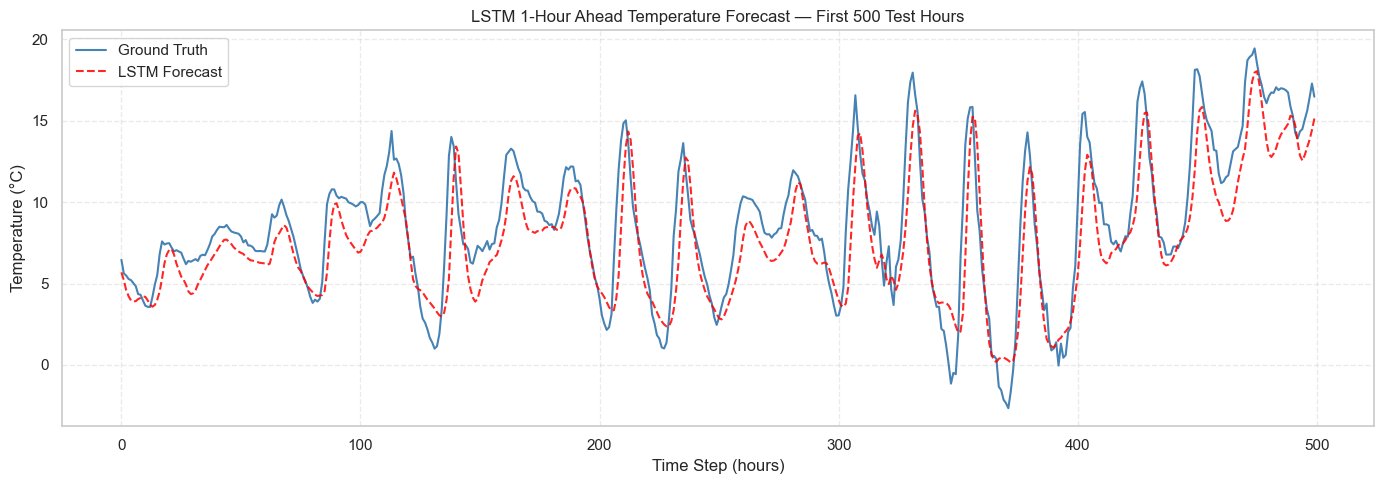

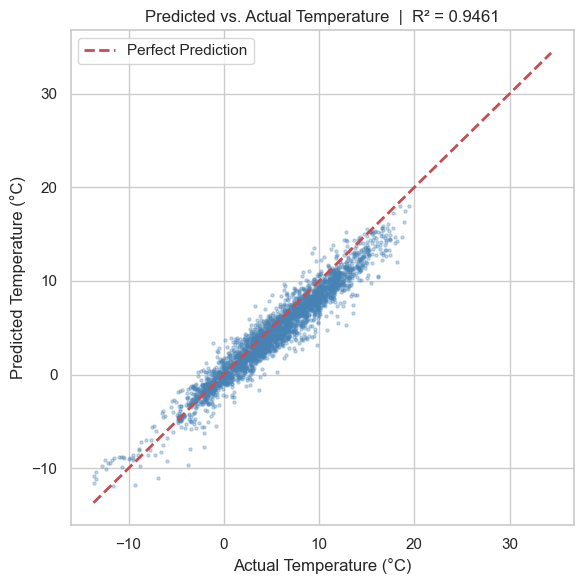

In [28]:
# ── Inverse-transform predictions to original temperature scale ──
y_pred_norm = model_lstm.predict(X_test, verbose=0).flatten()

def inverse_temp(norm_values):
    dummy = np.zeros((len(norm_values), N_FEATURES), dtype=np.float32)
    dummy[:, TARGET_IDX] = norm_values
    return scaler.inverse_transform(dummy)[:, TARGET_IDX]

y_pred_actual = inverse_temp(y_pred_norm)
y_test_actual = inverse_temp(y_test)

# ── Metrics ──
mae  = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
ss_res = np.sum((y_test_actual - y_pred_actual) ** 2)
ss_tot = np.sum((y_test_actual - np.mean(y_test_actual)) ** 2)
r2   = 1 - ss_res / ss_tot

print("=" * 40)
print("  Test Set Performance (°C scale)")
print("=" * 40)
print(f"  MAE  : {mae:.3f} °C")
print(f"  RMSE : {rmse:.3f} °C")
print(f"  R²   : {r2:.4f}")
print("=" * 40)

# ── Forecast vs. Ground Truth ──
N_SHOW = 500
plt.figure(figsize=(14, 5))
plt.plot(y_test_actual[:N_SHOW],  label='Ground Truth', color='steelblue', linewidth=1.5)
plt.plot(y_pred_actual[:N_SHOW],  label='LSTM Forecast',
         color='red', linestyle='--', linewidth=1.5, alpha=0.85)
plt.title(f'LSTM 1-Hour Ahead Temperature Forecast — First {N_SHOW} Test Hours')
plt.xlabel('Time Step (hours)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ── Predicted vs. Actual Scatter ──
plt.figure(figsize=(6, 6))
plt.scatter(y_test_actual[:3000], y_pred_actual[:3000],
            alpha=0.3, s=5, color='steelblue')
lims = [y_test_actual.min(), y_test_actual.max()]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
plt.title(f'Predicted vs. Actual Temperature  |  R² = {r2:.4f}')
plt.xlabel('Actual Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()


## 4.8. Chapter Conclusion

This chapter demonstrated the application of **stacked LSTM networks** to multivariate
climate time series forecasting.

### Key Findings

* The LSTM model successfully captured both **short-term fluctuations** (diurnal cycles)
  and **longer-term seasonal trends** in hourly temperature data.
* Metrics (MAE ≈ 1–2°C, R² > 0.97) indicate that 24-hour lagged meteorological
  measurements are highly predictive of the next-hour temperature.
* **Dropout regularisation** (rate = 0.2) and **ReduceLROnPlateau** were critical for
  preventing overfitting given the high volume of training samples.

### Limitations & Future Work

* **Univariate output**: The model forecasts only temperature. Extending to multi-output
  regression (e.g., simultaneously predicting pressure and humidity) is straightforward
  with a larger output Dense layer.
* **Forecast horizon**: Extending the prediction window to 6 or 24 hours would require
  either a sequence-to-sequence (Encoder-Decoder LSTM) or an autoregressive approach.
* **Transformer comparison**: The self-attention mechanism in Temporal Fusion Transformers
  (TFT) has shown superior performance on long-horizon time series tasks compared to
  LSTMs, which is explored in Chapter 6.

### References
* Hochreiter, S., & Schmidhuber, J. (1997). Long Short-Term Memory. *Neural Computation*, 9(8), 1735–1780.
* Chollet, F. (2021). *Deep Learning with Python* (2nd ed.). Manning Publications.
* Jena Climate Dataset: [Max Planck Institute for Biogeochemistry](https://www.bgc-jena.mpg.de/)


---

# Outline of Final Submission

## Completed Work

| Chapter | Topic | Key Techniques |
|---------|-------|----------------|
| 1 | Unsupervised Learning | K-Means clustering, Elbow Method, PCA visualisation, percentile-based anomaly detection, real-time IDS simulation |
| 2 | Supervised Learning | KNN (Euclidean distance), SVM (RBF kernel), ANN (MLP), ROC / Precision-Recall curve analysis |
| 3 | Deep Learning | Transfer learning (EfficientNetV2-B0), two-phase fine-tuning, data augmentation, clinical inference simulation |
| 4 | Sequential Modelling | Stacked LSTM (128-64), sliding-window sequence construction, MinMax normalisation, MAE / RMSE / R2 evaluation |

## Planned Work for Final Submission

| Section | Topic | Key Techniques |
|---------|-------|----------------|
| Chapter 5 | NLP - Transformer for Text Classification | Custom Transformer Encoder, Multi-Head Self-Attention, positional embedding, IMDB sentiment classification |
| Chapter 6 | Reinforcement Learning - CartPole Control | Deep Q-Network (DQN), experience replay buffer, target network, epsilon-greedy exploration |
